Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

PCA Transformed Data Shape:
(200, 2)

Explained Variance Ratio:
[0.50495142 0.49504858]


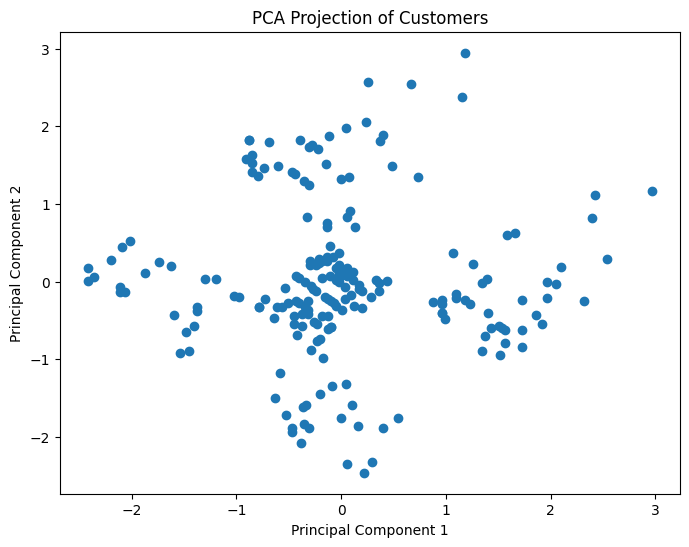


K-MEANS CLUSTERING


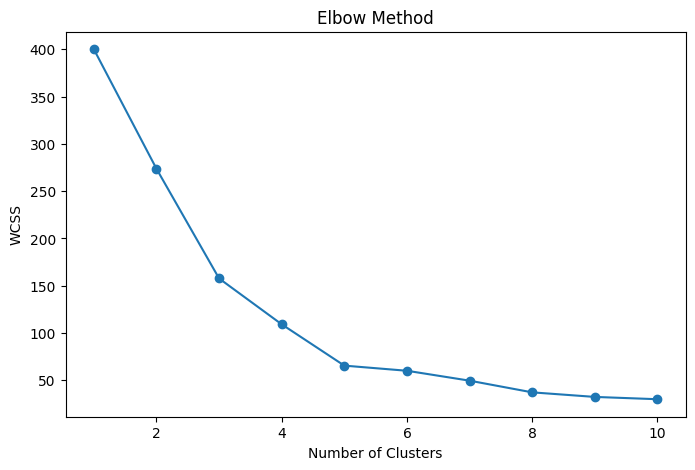

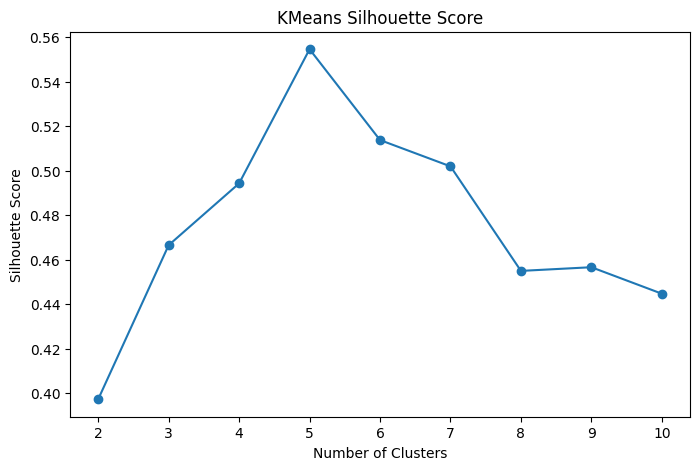


KMeans Silhouette Score: 0.5546571631100179

DBSCAN


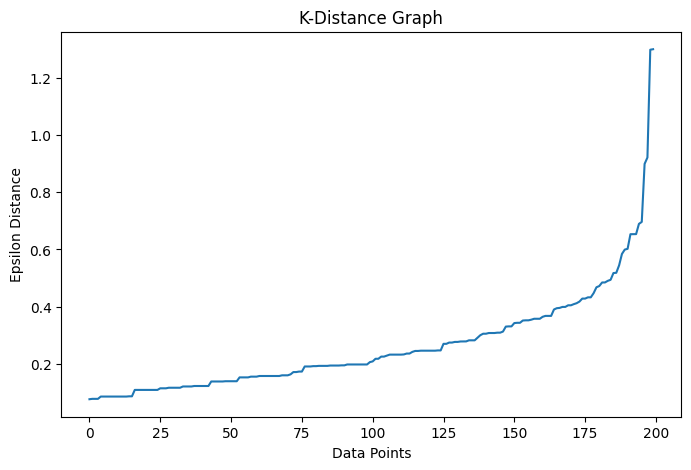


DBSCAN could not form proper clusters

DBSCAN Cluster Distribution:
 0    157
 1     35
-1      8
Name: count, dtype: int64

AGGLOMERATIVE CLUSTERING


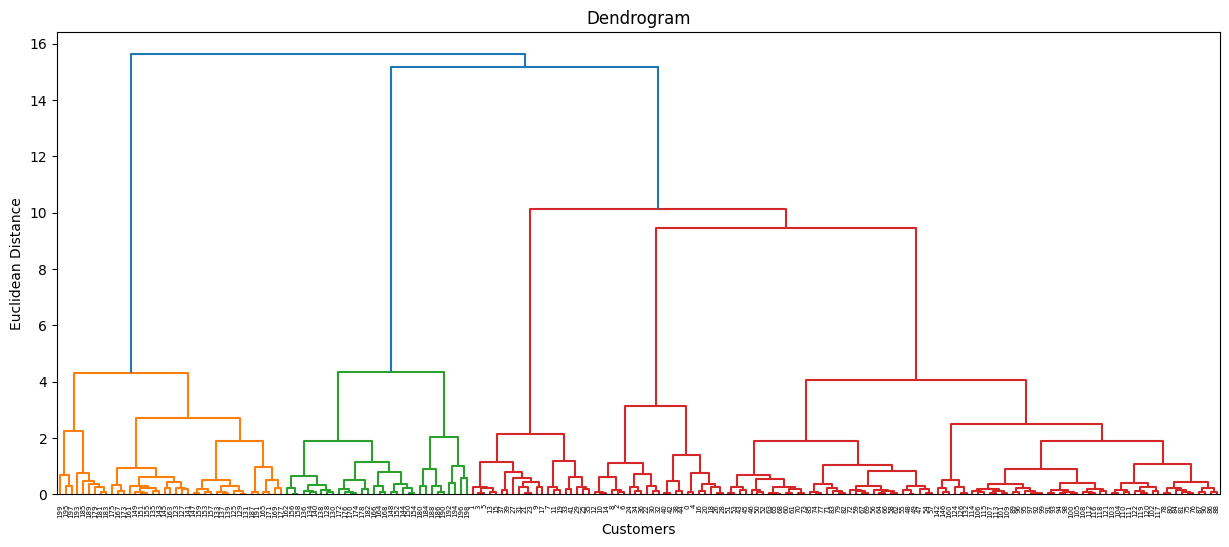

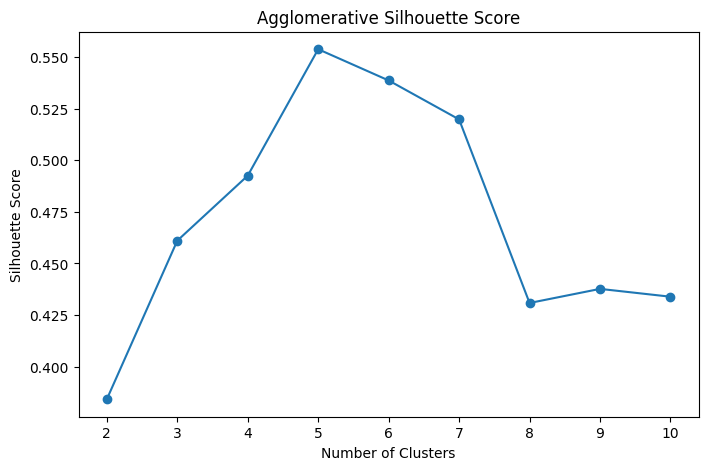


Agglomerative Silhouette Score: 0.5538089226678585

FINAL COMPARISON
KMeans Score        : 0.5546571631100179
DBSCAN Score        : -1
Agglomerative Score : 0.5538089226678585

Best Algorithm is: KMeans


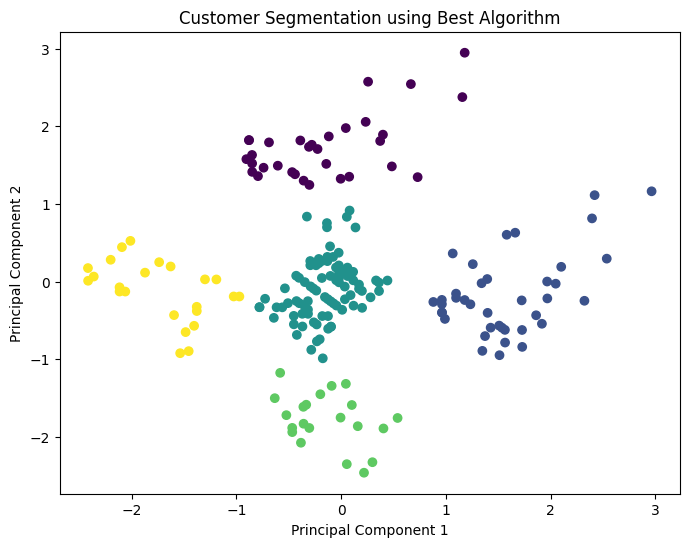


Final Dataset with Cluster Labels:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   KMeans_Cluster  DBSCAN_Cluster  Agglomerative_Cluster  
0               4               0                      4  
1               2               0                      3  
2               4               0                      4  
3               2               0                      3  
4               4               0                      4  


In [13]:
# ==========================================
# CUSTOMER SEGMENTATION WITH PCA
# KMEANS vs DBSCAN vs AGGLOMERATIVE
# ==========================================

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sc

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("/content/Mall_Customers.csv")

print("Dataset Preview:")
print(df.head())

# ==========================================
# DATA PREPROCESSING
# ==========================================

# Encode Gender

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

# Select Features

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# APPLY PCA
# ==========================================

# Reduce dimensions to 2 Principal Components

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Transformed Data Shape:")
print(X_pca.shape)

# Explained Variance Ratio

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# PCA Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection of Customers")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

# ==========================================
# K-MEANS CLUSTERING
# ==========================================

print("\n==========================================")
print("K-MEANS CLUSTERING")
print("==========================================")

# Elbow Method

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

# Silhouette Scores

silhouette_scores_kmeans = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    silhouette_scores_kmeans.append(score)

# Plot Silhouette Scores

plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores_kmeans, marker='o')

plt.title("KMeans Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.show()

# Final KMeans

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_pca)

df["KMeans_Cluster"] = kmeans_labels

kmeans_score = silhouette_score(X_pca, kmeans_labels)

print("\nKMeans Silhouette Score:", kmeans_score)

# ==========================================
# DBSCAN
# ==========================================

print("\n==========================================")
print("DBSCAN")
print("==========================================")

# K-Distance Graph

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:,4], axis=0)

plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("K-Distance Graph")

plt.xlabel("Data Points")

plt.ylabel("Epsilon Distance")

plt.show()

# Apply DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_pca)

df["DBSCAN_Cluster"] = dbscan_labels

# DBSCAN Score

unique_clusters = set(dbscan_labels)

if len(unique_clusters) > 1 and -1 not in unique_clusters:

    dbscan_score = silhouette_score(X_pca, dbscan_labels)

    print("\nDBSCAN Silhouette Score:", dbscan_score)

else:

    print("\nDBSCAN could not form proper clusters")

    dbscan_score = -1

# Cluster Distribution

print("\nDBSCAN Cluster Distribution:")

print(pd.Series(dbscan_labels).value_counts())

# ==========================================
# AGGLOMERATIVE CLUSTERING
# ==========================================

print("\n==========================================")
print("AGGLOMERATIVE CLUSTERING")
print("==========================================")

# Dendrogram

plt.figure(figsize=(15,6))

sc.dendrogram(
    sc.linkage(
        X_pca,
        method='ward'
    )
)

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

# Silhouette Scores

silhouette_scores_agglo = []

for k in range(2,11):

    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = agglo.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    silhouette_scores_agglo.append(score)

# Plot Scores

plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores_agglo, marker='o')

plt.title("Agglomerative Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.show()

# Final Agglomerative

agglo = AgglomerativeClustering(
    n_clusters=5
)

agglo_labels = agglo.fit_predict(X_pca)

df["Agglomerative_Cluster"] = agglo_labels

agglo_score = silhouette_score(X_pca, agglo_labels)

print("\nAgglomerative Silhouette Score:", agglo_score)

# ==========================================
# FINAL COMPARISON
# ==========================================

print("\n==========================================")
print("FINAL COMPARISON")
print("==========================================")

print("KMeans Score        :", kmeans_score)

print("DBSCAN Score        :", dbscan_score)

print("Agglomerative Score :", agglo_score)

# Best Algorithm

scores = {
    "KMeans": kmeans_score,
    "DBSCAN": dbscan_score,
    "Agglomerative": agglo_score
}

best_algorithm = max(scores, key=scores.get)

print("\nBest Algorithm is:", best_algorithm)

# ==========================================
# FINAL PCA CLUSTER VISUALIZATION
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agglo_labels
)

plt.title("Customer Segmentation using Best Algorithm")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

# ==========================================
# FINAL DATASET
# ==========================================

print("\nFinal Dataset with Cluster Labels:")

print(df.head())